In [4]:
from google.colab import drive
import os
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
dataset_path = "/content/drive/MyDrive/Deep-Learning-Image-Classification/Dataset"


train_path = dataset_path + "/train"
test_path = dataset_path + "/test"
val_path = dataset_path + "/val"


print(os.listdir(train_path))

['forest', 'street', 'mountain', 'buildings', 'sea', 'glacier']


# **Image Resizing**

**set image size**

In [2]:
import tensorflow as tf

print(tf.__version__)

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32


2.20.0


**Create Training Dataset Loader**

In [6]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
train_path,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=BATCH_SIZE
)

Found 12632 files belonging to 6 classes.


**Create validating Dataset Loader**


In [7]:
val_dataset = tf.keras.utils.image_dataset_from_directory(
val_path,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=BATCH_SIZE
)

Found 1402 files belonging to 6 classes.


**Create Testing Dataset Loader**

In [8]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
test_path,
image_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=BATCH_SIZE,
shuffle=False
)

Found 3000 files belonging to 6 classes.


**Check Class Names**

In [12]:
class_names = train_dataset.class_names
print(class_names)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


**Display Loaded Images**

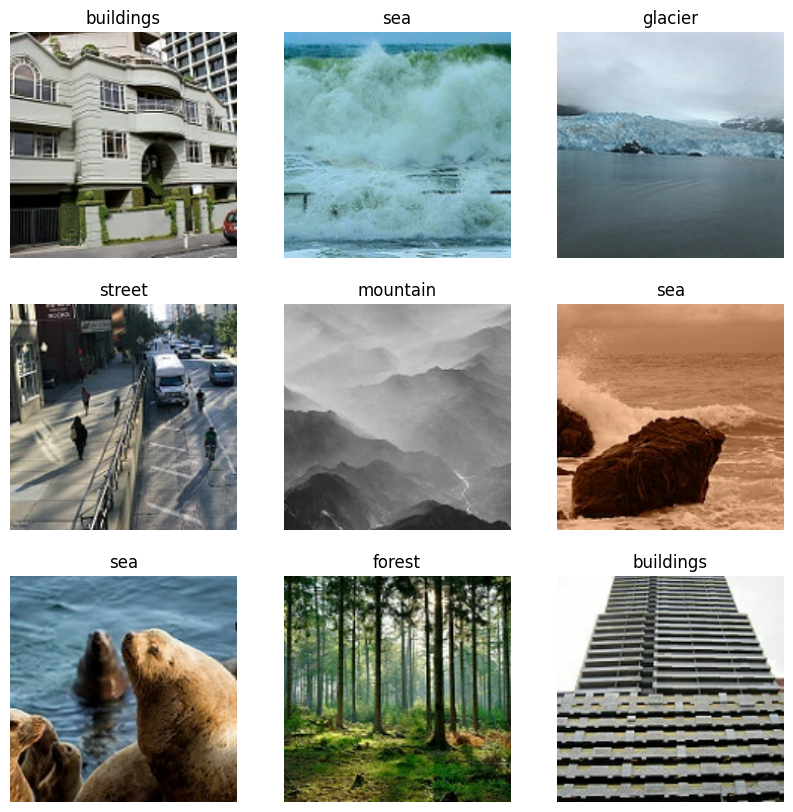

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

# Data Normalization

In [13]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

In [14]:
normalized_dataset = train_dataset.map(
lambda x, y: (normalization_layer(x), y)
)

In [15]:
for image_batch, labels_batch in normalized_dataset.take(1):

    print(image_batch[0].numpy().min())
    print(image_batch[0].numpy().max())

0.0
0.9901033


# Data Augmentation

**Create Augmentation Layer**

In [16]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.1
    )
])

**Visualize Augmented Images**

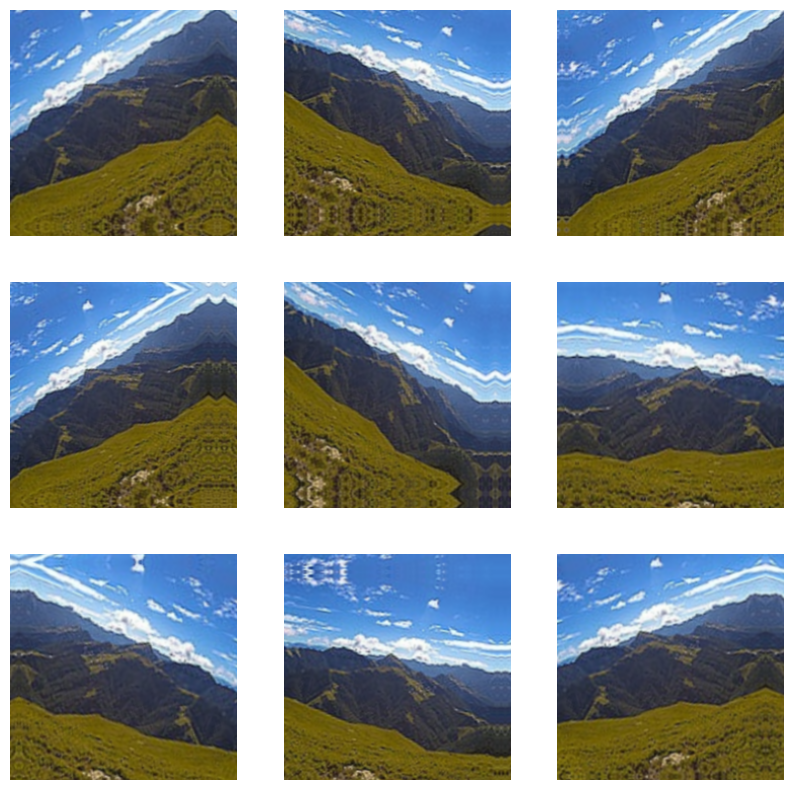

In [17]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):

    first_image = images[0]

    plt.figure(figsize=(10,10))

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        augmented_image = data_augmentation(
            tf.expand_dims(first_image,0)
        )

        plt.imshow(
            augmented_image[0].numpy().astype("uint8")
        )

        plt.axis("off")

    plt.show()